<a href="https://colab.research.google.com/github/Dounia-Awni/Adult_Income_Project/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Load Data

In [17]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd
path='/content/drive/MyDrive/AXSOSACADEMY/03-IntermediateML/Week17/Data/adult.csv'
df=pd.read_csv(path)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


#2. Exploaring and Cleaning Data

In [20]:
df.shape

(48842, 15)

In [21]:
cat = df.select_dtypes('object').columns
cat

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

In [22]:
for col in cat:
    print(f"Column: {col}")
    print(df[col].nunique())
    print("\n" + "-"*30 + "\n")

Column: workclass
9

------------------------------

Column: education
16

------------------------------

Column: marital-status
7

------------------------------

Column: occupation
15

------------------------------

Column: relationship
6

------------------------------

Column: race
5

------------------------------

Column: gender
2

------------------------------

Column: native-country
42

------------------------------

Column: income
2

------------------------------



In [23]:
duplicates = df.duplicated().sum()
duplicates

np.int64(52)

In [26]:
df = df.drop_duplicates()
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [28]:
null = df.isna().sum().sum()
null

np.int64(0)

In [29]:
for col in cat:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n" + "-"*30 + "\n")

Column: workclass
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

------------------------------

Column: education
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

------------------------------

Column: marital-status
marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spous

In [33]:
import numpy as np
for col in cat:
    df[col] = df[col].replace('?', np.nan)

In [34]:
for col in cat:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n" + "-"*30 + "\n")

Column: workclass
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

------------------------------

Column: education
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

------------------------------

Column: marital-status
marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count

In [35]:
null = df.isna().sum()
null

,0
age,0
workclass,2795
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0


In [36]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object


In [37]:
df.describe().round(2)

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48790.00,48790.00,48790.00,48790.00,48790.00,48790.00
mean,38.65,189669.00,10.08,1080.22,87.60,40.43
std,13.71,105617.23,2.57,7455.91,403.21,12.39
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117555.00,9.00,0.00,0.00,40.00
50%,37.00,178138.50,10.00,0.00,0.00,40.00
75%,48.00,237606.25,12.00,0.00,0.00,45.00
max,90.00,1490400.00,16.00,99999.00,4356.00,99.00


In [39]:
# Identifies rows where 'capital-gain' is 99999 to investigate outliers.
capital_gain=df[df['capital-gain']==99999]
capital_gain

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
83,44,Self-emp-inc,223881,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,50,NaN,>50K
346,39,Private,198654,HS-grad,9,Divorced,Exec-managerial,Unmarried,Black,Female,99999,0,40,United-States,>50K
357,50,Self-emp-not-inc,165001,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,80,United-States,>50K
418,54,Self-emp-inc,159219,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,40,United-States,>50K
692,41,Private,191547,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,55,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48109,47,Private,155664,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,55,United-States,>50K
48253,43,Self-emp-inc,62026,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States,>50K
48371,66,Private,115498,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,55,NaN,>50K
48519,47,Private,294913,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States,>50K


In [42]:
print(f"Number of unique values in 'capital-gain': {df['capital-gain'].nunique()}")
display(df['capital-gain'].value_counts().head())

Number of unique values in 'capital-gain': 123


,count
capital-gain,
0,44755
15024,513
7688,410
7298,364
99999,244


In [43]:
# Identifies rows where 'hours-per-week' is 99 to investigate outliers.
hours_per_week=df[df['hours-per-week']==99]
hours_per_week

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
384,29,Private,211208,11th,7,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,99,United-States,>50K
901,37,Private,112158,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7688,0,99,United-States,>50K
1121,31,Local-gov,378426,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,99,Columbia,<=50K
1156,48,NaN,117054,5th-6th,3,Divorced,NaN,Not-in-family,White,Male,0,0,99,United-States,<=50K
1649,52,Private,254680,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,99,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47273,40,Self-emp-inc,104235,Masters,14,Never-married,Other-service,Own-child,White,Male,0,0,99,United-States,<=50K
47962,43,Private,266324,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,1902,99,United-States,>50K
47980,43,Self-emp-not-inc,163108,Some-college,10,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,99,United-States,<=50K
48750,58,Self-emp-inc,181974,Doctorate,16,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,99,NaN,<=50K


In [44]:
#Saving the cleaned data to Google Drive
f_path="/content/drive/MyDrive/AXSOSACADEMY/03-IntermediateML/Week17/Data/Cleaned-adult.csv"
df.to_csv(f_path,index=False)

#3. Exploratory Visualizations

In [45]:
#import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
#Load Data
path="/content/drive/MyDrive/AXSOSACADEMY/03-IntermediateML/Week17/Data/Cleaned-adult.csv"
df=pd.read_csv(path)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48790 entries, 0 to 48789
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48790 non-null  int64 
 1   workclass        45995 non-null  object
 2   fnlwgt           48790 non-null  int64 
 3   education        48790 non-null  object
 4   educational-num  48790 non-null  int64 
 5   marital-status   48790 non-null  object
 6   occupation       45985 non-null  object
 7   relationship     48790 non-null  object
 8   race             48790 non-null  object
 9   gender           48790 non-null  object
 10  capital-gain     48790 non-null  int64 
 11  capital-loss     48790 non-null  int64 
 12  hours-per-week   48790 non-null  int64 
 13  native-country   47934 non-null  object
 14  income           48790 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [47]:
"""UNIVARIATE PLOTTING FUNCTIONS FOR EDA"""
# Add the print statements to the function
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',figsize = (6,4), order = None):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax



def explore_numeric(df, x, figsize=(6,5) ):

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

  """MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

# Updating function
def plot_categorical_vs_target(df, x, y, figsize=(6,4),
                               fillna = True, placeholder = 'MISSING',
                               order = None, target_type='reg'):
    # Make a copy of the dataframe and fillna
    temp_df = df.copy()
    # fillna with placeholder
    if fillna == True:
        temp_df[x] = temp_df[x].fillna(placeholder)
    # or drop nulls prevent unwanted 'nan' group in stripplot
    else:
        temp_df = temp_df.dropna(subset=[x])
    # Create the figure and subplots
    fig, ax = plt.subplots(figsize=figsize)
    # REGRESSION-TARGET PLOT
    if target_type=='reg': #Added if statement here
        # Barplot
        sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                    linewidth=1, edgecolor='black', errorbar=None)

        # Boxplot
        sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                      order=order, hue_order=order, legend=False,
                      edgecolor='white', linewidth=0.5,
                      size=3,zorder=0)

    # CLASSIFICATION-TARGET PLOT # This is the new code for the classification task
    elif target_type=='class':
        ax = sns.histplot(data=temp_df, hue=y, x=x, stat='percent', multiple='fill')
    # Rotate xlabels
    ax.set_xticks(ax.get_xticks()) # Added this to prevent a bug
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    # Add a title
    ax.set_title(f"{x} vs. {y}")
    fig.tight_layout()
    return fig, ax

    # Updating the function
def plot_numeric_vs_target(df, x, y, figsize=(6,4),
                           target_type='reg', estimator='mean',
                           errorbar='ci',sorted=False,ascending=False,
                           **kwargs): # kwargs for sns.regplot

    nulls = df[[x,y]].isna().sum()
    if nulls.sum()>0:
        print(f"- Excluding {nulls.sum()} NaN's")
        # print(nulls)
        temp_df = df.dropna(subset=[x,y])
    else:
        temp_df = df
    # Create the figure
    fig, ax = plt.subplots(figsize=figsize)

    # REGRESSION-TARGET PLOT
    if 'reg' in target_type:
        # Calculate the correlation
        corr = df[[x,y]].corr().round(2)
        r = corr.loc[x,y]
        # Plot the data
        scatter_kws={'ec':'white','lw':1,'alpha':0.8}
        sns.regplot(data=temp_df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs)
        # Included the new argument within the sns.regplot function
        ## Add the title with the correlation
        ax.set_title(f"{x} vs. {y} (r = {r})")

    # CLASSIFICATION-TARGET PLOT
    elif 'class' in target_type:

        # Sort the groups by median/mean
        if sorted == True:

            if estimator == 'median':
                group_vals = temp_df.groupby(y)[x].median()
            elif estimator =='mean':
                group_vals = temp_df.groupby(y)[x].mean()

            ## Sort values
            group_vals = group_vals.sort_values(ascending=ascending)
            order = group_vals.index

        else:
            # Set order to None if not calculated
            order = None

        # Left Subplot (barplot)
        sns.barplot(data=temp_df, x=y, y=x, order=order, estimator=estimator,
                    errorbar=errorbar, ax=ax, **kwargs)

        # Add title
        ax.set_title(f"{x} vs. {y}")

        # rotate xaxis labels
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Final Adjustments & return
    fig.tight_layout()
    fig.show()
    return fig, ax

### Correlation Analysis with Target Variable

In [49]:
target=df['income']
target.value_counts()

,count
income,
<=50K,37109
>50K,11681


In [50]:
# Convert 'income' column to numerical (0 for <=50K, 1 for >50K)
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)
display(df[['income']].head())

,income
0,0
1,0
2,1
3,1
4,0


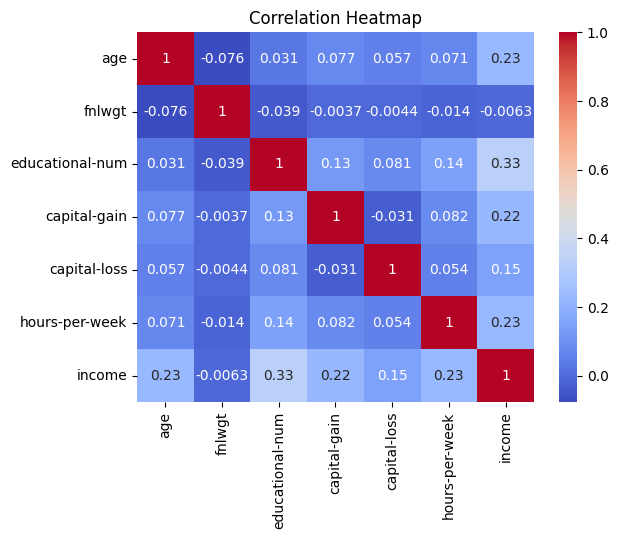

In [51]:
#Heatmap to view the correlation between numeric features and the target
corr=df.corr(numeric_only=True)
ax=sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title('Correlation Heatmap');

Based on the correlation heatmap (which shows correlations of all features with each other, including the target), the strongest predictors for income appear to be:

1. educational-num (0.33)
2. age (0.24)
3. hours-per-week (0.23)
4. capital-gain (0.22)

* These features show the highest positive correlation with the income variable, meaning as their values increase, the likelihood of a higher income ('>50K') tends to increase as well.

##Explore each feature

###1. Numeric features

In [54]:
num = df.select_dtypes('number').columns
num

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income'],
      dtype='object')

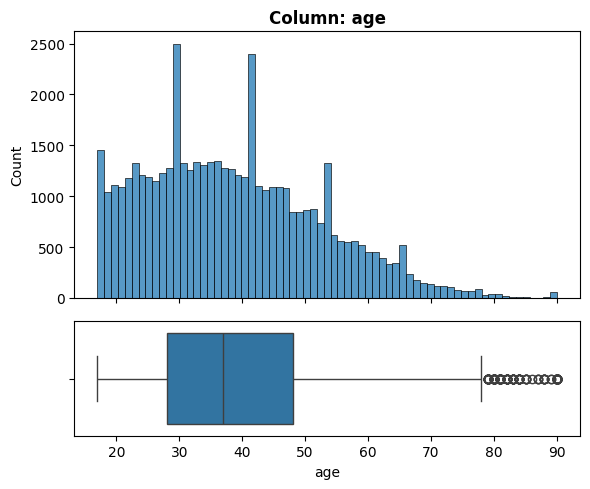

- NaN's Found: 0 (0.0%)
- Unique Values: 74
- Most common value: '36' occurs 1348 times (2.76%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: age'}, xlabel='age', ylabel='Count'>,
        <Axes: xlabel='age'>], dtype=object))

In [52]:
# plot for age column
feature = 'age'
explore_numeric(df, feature)

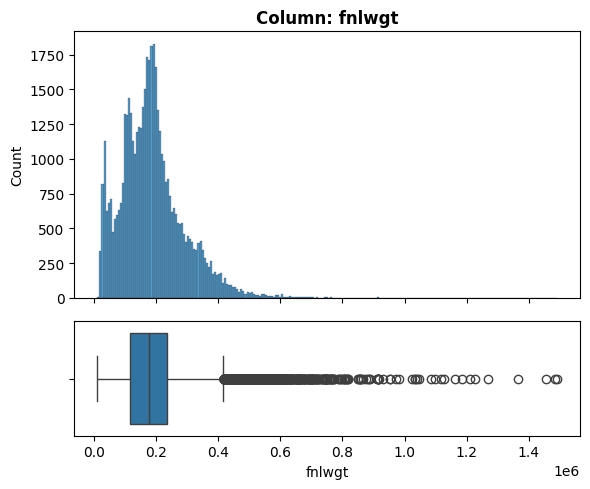

- NaN's Found: 0 (0.0%)
- Unique Values: 28523
- Most common value: '203488' occurs 21 times (0.04%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: fnlwgt'}, xlabel='fnlwgt', ylabel='Count'>,
        <Axes: xlabel='fnlwgt'>], dtype=object))

In [53]:
# plot for fnlwgt column
feature = 'fnlwgt'
explore_numeric(df, feature)

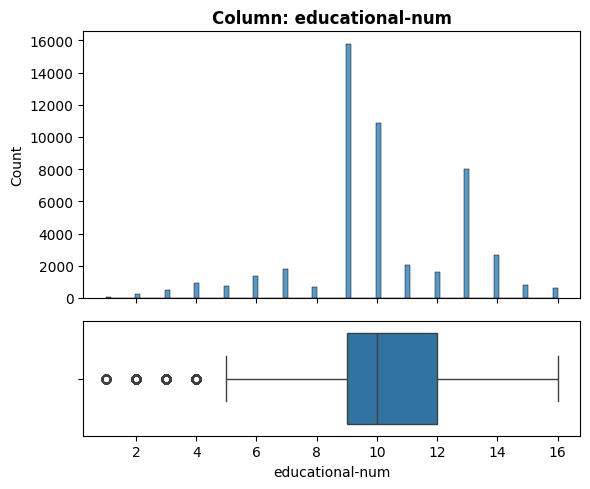

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: '9' occurs 15770 times (32.32%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: educational-num'}, xlabel='educational-num', ylabel='Count'>,
        <Axes: xlabel='educational-num'>], dtype=object))

In [55]:
# plot for educational-num column
feature = 'educational-num'
explore_numeric(df, feature)

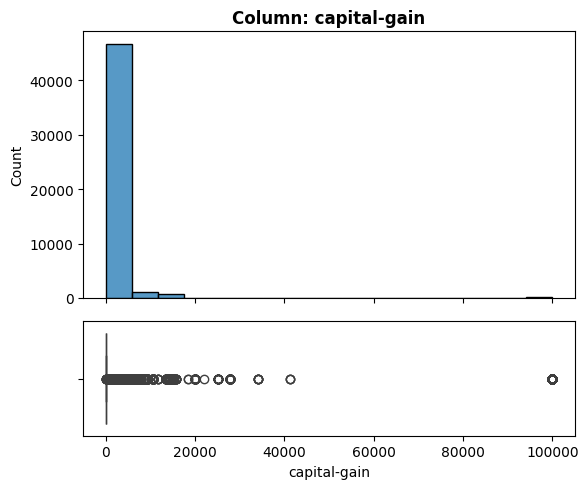

- NaN's Found: 0 (0.0%)
- Unique Values: 123
- Most common value: '0' occurs 44755 times (91.73%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: capital-gain'}, xlabel='capital-gain', ylabel='Count'>,
        <Axes: xlabel='capital-gain'>], dtype=object))

In [56]:
# plot for capital-gain column
feature = 'capital-gain'
explore_numeric(df, feature)

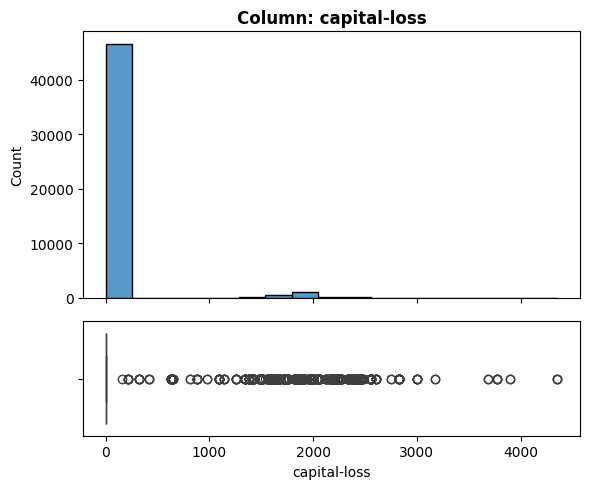

- NaN's Found: 0 (0.0%)
- Unique Values: 99
- Most common value: '0' occurs 46508 times (95.32%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: capital-loss'}, xlabel='capital-loss', ylabel='Count'>,
        <Axes: xlabel='capital-loss'>], dtype=object))

In [57]:
# plot for capital-loss column
feature = 'capital-loss'
explore_numeric(df, feature)

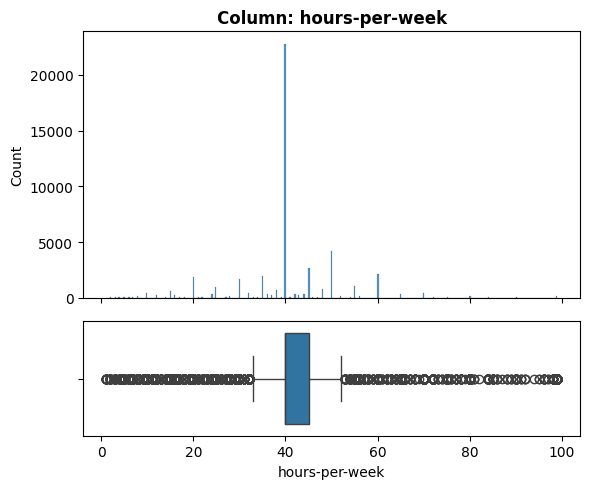

- NaN's Found: 0 (0.0%)
- Unique Values: 96
- Most common value: '40' occurs 22773 times (46.68%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: hours-per-week'}, xlabel='hours-per-week', ylabel='Count'>,
        <Axes: xlabel='hours-per-week'>], dtype=object))

In [58]:
# plot for hours-per-week column
feature = 'hours-per-week'
explore_numeric(df, feature)

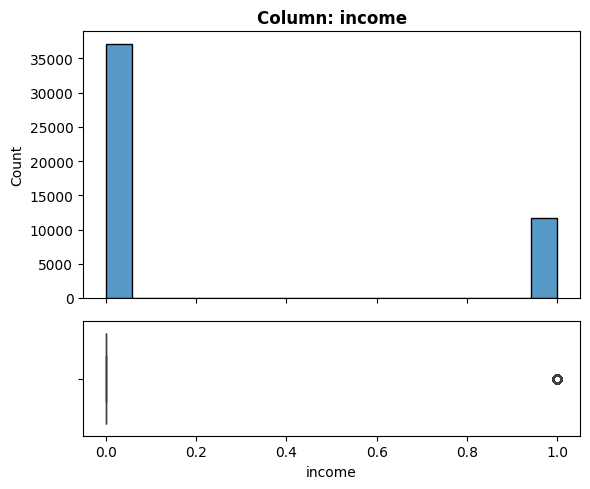

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: '0' occurs 37109 times (76.06%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: income'}, xlabel='income', ylabel='Count'>,
        <Axes: xlabel='income'>], dtype=object))

In [59]:
# plot for income column
feature = 'income'
explore_numeric(df, feature)

###2. Categorical features

In [60]:
cat = df.select_dtypes('object').columns
cat

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object')

/tmp/ipykernel_2144/798643945.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


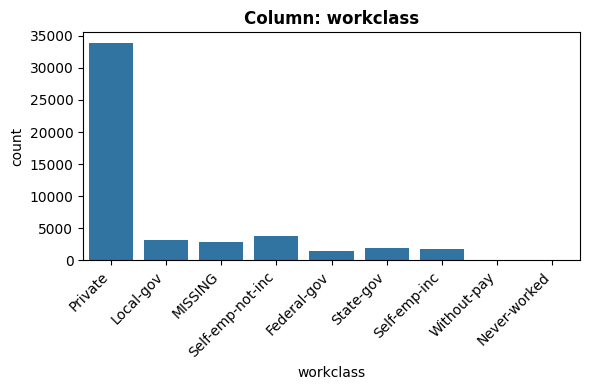

- NaN's Found: 2795 (5.73%)
- Unique Values: 9
- Most common value: 'Private' occurs 33860 times (69.4%)
- Not constant or quasi-constant.


In [61]:
# plot for workclass feature
feature = 'workclass'
explore_categorical(df, feature, fillna=True);

/tmp/ipykernel_2144/798643945.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


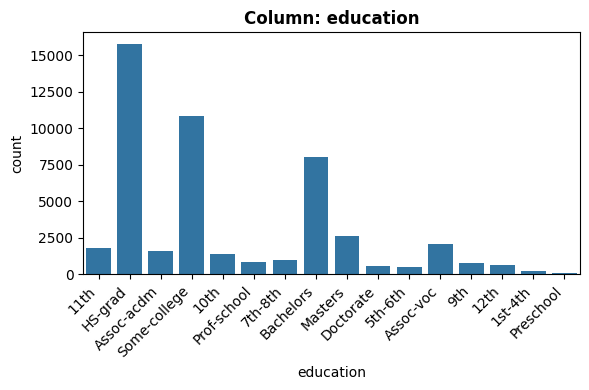

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'HS-grad' occurs 15770 times (32.32%)
- Not constant or quasi-constant.


In [62]:
# plot for education feature
feature = 'education'
explore_categorical(df, feature, fillna=True);

/tmp/ipykernel_2144/798643945.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


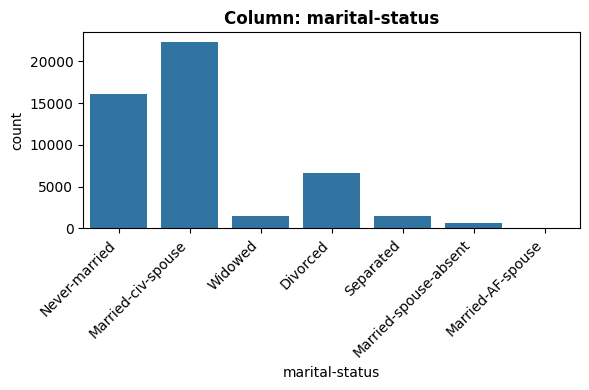

- NaN's Found: 0 (0.0%)
- Unique Values: 7
- Most common value: 'Married-civ-spouse' occurs 22366 times (45.84%)
- Not constant or quasi-constant.


In [63]:
# plot for marital-status feature
feature = 'marital-status'
explore_categorical(df, feature, fillna=True);

/tmp/ipykernel_2144/798643945.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


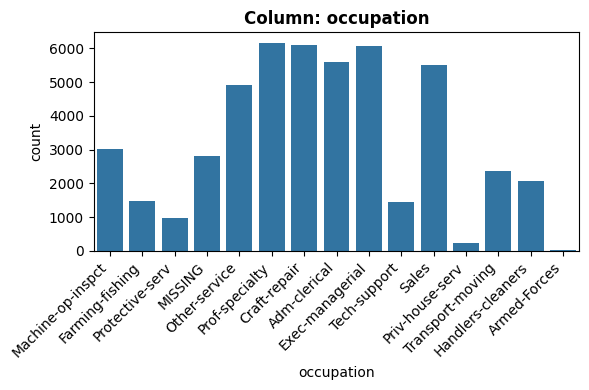

- NaN's Found: 2805 (5.75%)
- Unique Values: 15
- Most common value: 'Prof-specialty' occurs 6165 times (12.64%)
- Not constant or quasi-constant.


In [64]:
# plot for occupation feature
feature = 'occupation'
explore_categorical(df, feature, fillna=True);

/tmp/ipykernel_2144/798643945.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


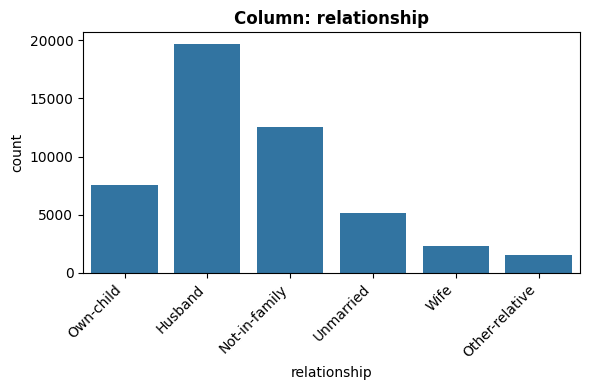

- NaN's Found: 0 (0.0%)
- Unique Values: 6
- Most common value: 'Husband' occurs 19703 times (40.38%)
- Not constant or quasi-constant.


In [65]:
# plot for relationship feature
feature = 'relationship'
explore_categorical(df, feature, fillna=True);

/tmp/ipykernel_2144/798643945.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


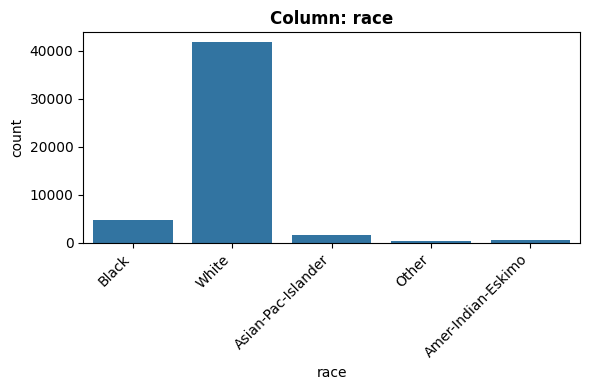

- NaN's Found: 0 (0.0%)
- Unique Values: 5
- Most common value: 'White' occurs 41714 times (85.5%)
- Not constant or quasi-constant.


In [66]:
# plot for race feature
feature = 'race'
explore_categorical(df, feature, fillna=True);

/tmp/ipykernel_2144/798643945.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


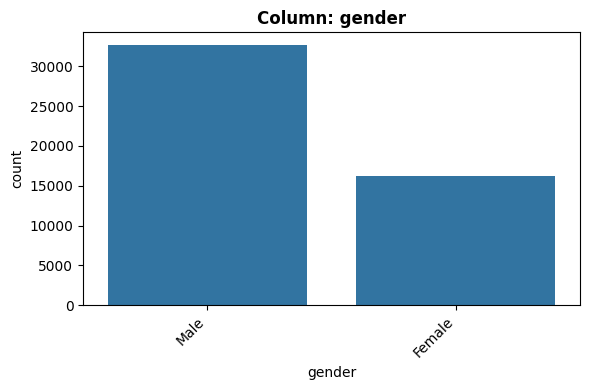

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Male' occurs 32614 times (66.85%)
- Not constant or quasi-constant.


In [67]:
# plot for gender feature
feature = 'gender'
explore_categorical(df, feature, fillna=True);

/tmp/ipykernel_2144/798643945.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


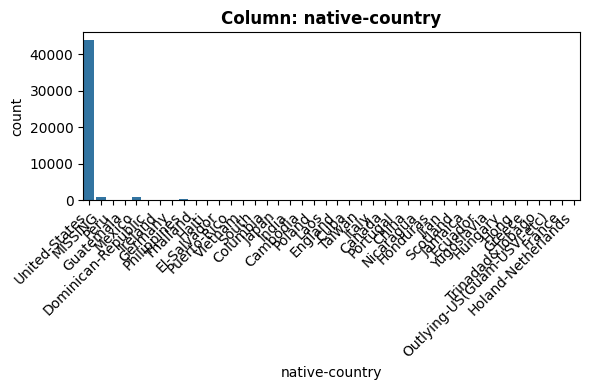

- NaN's Found: 856 (1.75%)
- Unique Values: 42
- Most common value: 'United-States' occurs 43792 times (89.76%)
- Not constant or quasi-constant.


In [68]:
# plot for native-country feature
feature = 'native-country'
explore_categorical(df, feature, fillna=True);

#4. Machine learning

In [71]:
#Load Data
path="/content/drive/MyDrive/AXSOSACADEMY/03-IntermediateML/Week17/Data/Cleaned-adult.csv"
df=pd.read_csv(path)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48790 entries, 0 to 48789
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48790 non-null  int64 
 1   workclass        45995 non-null  object
 2   fnlwgt           48790 non-null  int64 
 3   education        48790 non-null  object
 4   educational-num  48790 non-null  int64 
 5   marital-status   48790 non-null  object
 6   occupation       45985 non-null  object
 7   relationship     48790 non-null  object
 8   race             48790 non-null  object
 9   gender           48790 non-null  object
 10  capital-gain     48790 non-null  int64 
 11  capital-loss     48790 non-null  int64 
 12  hours-per-week   48790 non-null  int64 
 13  native-country   47934 non-null  object
 14  income           48790 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [72]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('income', axis=1)
y = df['income']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_train.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
38062,82,NaN,194590,Assoc-voc,11,Widowed,NaN,Not-in-family,White,Female,0,0,8,United-States
43350,30,State-gov,48214,Masters,14,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,0,50,United-States
3063,28,Private,340269,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,3137,0,45,United-States
45560,20,NaN,133515,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,15,France
2115,39,Private,67433,HS-grad,9,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States


In [75]:
#Check the target categories balance
y_train.value_counts(normalize=True)

,proportion
income,
<=50K,0.760849
>50K,0.239151


In [73]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
def classification_metrics(y_true, y_pred, label='',
                          output_dict=False, figsize=(8,4),
                          normalize='true', cmap='Blues',
                          colorbar=False):

    # Get the classification report
    report = classification_report(y_true, y_pred)

    ## Print header and report
    header = '='*70
    print(header, f' Classification Metrics: {label}', header, sep='\n')
    print(report)

    ## CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # create a confusion matrix of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                            normalize=None, cmap='gist_gray', colorbar=colorbar,
                                            ax = axes[0],)
    axes[0].set_title("Raw Counts")

    # create a confusion matrix with the test data
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                            normalize=normalize, cmap=cmap, colorbar=colorbar,
                                            ax = axes[1],)
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary of classification_report
    if output_dict==True:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                           figsize=(6,4), normalize='true', output_dict = False,
                           cmap_train='Blues', cmap_test='Reds', colorbar=False):

    # Get predictions for training data
    y_train_pred = model.predict(X_train)

    # Call the helper function to obtain regression metrics for training data
    results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                           output_dict=True, figsize=figsize,
                                           colorbar=colorbar, cmap=cmap_train,
                                           label='Training Data')
    print()

    # Get predictions for test data
    y_test_pred = model.predict(X_test)

    # Call the helper function to obtain regression metrics for test data
    results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                          output_dict=True, figsize=figsize,
                                          colorbar=colorbar, cmap=cmap_test,
                                          label='Test Data')

    if output_dict == True:
        # Store results in a dataframe if ouput_frame is True
        results_dict = {'train':results_train,
                        'test': results_test}

        return results_dict


In [76]:
# Prepare Categorical pipeline
cat_cols = X_train.select_dtypes('object').columns

#Impute missing values by MISSING
impute_cat= SimpleImputer(strategy='constant',fill_value='MISSING')

#Encode categorical features by one hot encoder
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

#Make a pipeline for the transformers
cat_pipe = make_pipeline(impute_cat, cat_encoder)
cat_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='MISSING', strategy='constant')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [77]:
# Prepare numeric piepline
num_cols = X_train.select_dtypes('number').columns

#Imputing null values by mean
imputer = SimpleImputer(strategy="median")

#Scaling numerical features
scaler = StandardScaler()

#Numeric Pipeline
numeric_pipe = make_pipeline(imputer, scaler)
numeric_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [78]:
#Making a numeric tuple for ColumnTransformer
num_tuple = ('numeric',numeric_pipe, num_cols)

#Making a categorical tuple for ColumnTransformer
cat_tuple = ('categorical',cat_pipe, cat_cols)

In [79]:
#Instantiate ColumnTransformer
col_trans = ColumnTransformer(transformers=[num_tuple,cat_tuple],verbose_feature_names_out=False)

##1. Logistic Regrission Model

In [80]:
from sklearn.linear_model import LogisticRegression
#Make an instance from the model
log_reg=LogisticRegression(max_iter=500,random_state=42)

#Make a model pipline includes the preprocessor and the model
log_reg_pipe=make_pipeline(col_trans,log_reg)

#Fitting the model pipline on the training data
log_reg_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImpute...lue='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('logisticregression',
                 LogisticRegression(max_iter=500, random_state=42))])

 Classification Metrics: Training Data
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91     27841
        >50K       0.74      0.60      0.66      8751

    accuracy                           0.85     36592
   macro avg       0.81      0.77      0.78     36592
weighted avg       0.85      0.85      0.85     36592



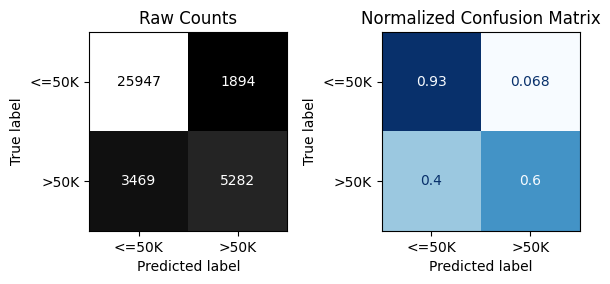


 Classification Metrics: Test Data
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      9268
        >50K       0.74      0.58      0.65      2930

    accuracy                           0.85     12198
   macro avg       0.81      0.76      0.78     12198
weighted avg       0.84      0.85      0.85     12198



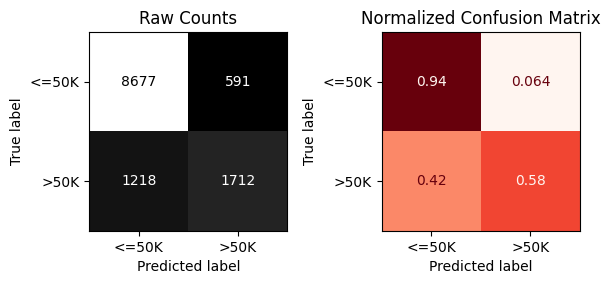

In [81]:
#Obtain evaluation metrics using custom function
evaluate_classification(log_reg_pipe, X_train, y_train, X_test, y_test)

In [82]:
#Git list of param for the logisticRegression pipeline to choose a list of hyperparameters for tunning
log_reg_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
          'hours-per-week'],
         dtype='object')),
                                   ('categorical',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='MISSING',
                                                                   strategy='constant')),
                                                    ('onehotencoder',
                                                     OneHotEnco

In [84]:
from sklearn.model_selection import GridSearchCV
#create param grid to use it with GridSearch CV
param_grid = [
    {
        "logisticregression__solver": ["liblinear"],
        "logisticregression__penalty": ["l1", "l2"],
        "logisticregression__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
        "logisticregression__class_weight": [None, "balanced"]
    },
    {
        "logisticregression__solver": ["lbfgs"],
        "logisticregression__penalty": ["l2"],
        "logisticregression__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
        "logisticregression__class_weight": [None, "balanced"]
    }
]

#Instantiate the GridSearchCV for hyperparameter tuning
grid = GridSearchCV(
    log_reg_pipe,
    param_grid,
    cv=3,
    scoring="recall_macro",
    n_jobs=-1
)
#Fitting the gridsearchcv on the training data
grid.fit(X_train, y_train)

#Print out the Best Parameters and Best Score after tuning
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'logisticregression__C': 0.1, 'logisticregression__class_weight': 'balanced', 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'lbfgs'}
Best Score: 0.8218770599000204


 Classification Metrics: Training Data
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.87     27841
        >50K       0.57      0.85      0.68      8751

    accuracy                           0.81     36592
   macro avg       0.76      0.82      0.77     36592
weighted avg       0.85      0.81      0.82     36592



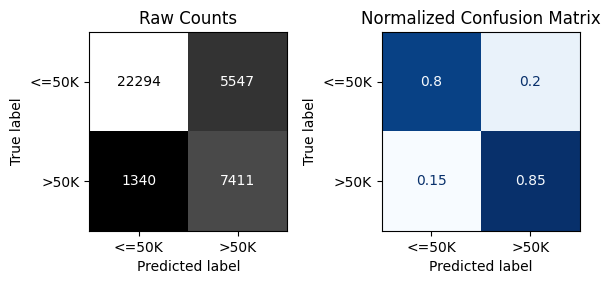


 Classification Metrics: Test Data
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.87      9268
        >50K       0.57      0.84      0.68      2930

    accuracy                           0.81     12198
   macro avg       0.76      0.82      0.77     12198
weighted avg       0.85      0.81      0.82     12198



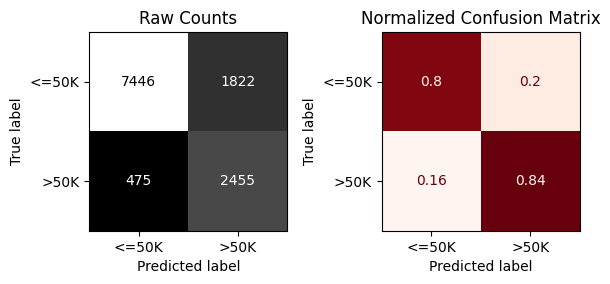

In [86]:
#Obtaining the best performing model
best_model = grid.best_estimator_

# Evaluate the optimized model
evaluate_classification(best_model, X_train, y_train, X_test, y_test)

##KNN Model

In [88]:
from sklearn.neighbors import KNeighborsClassifier
#Make an instance from the model
knn=KNeighborsClassifier()

#Make a model pipline includes the preprocessor and the model
knn_pipe=make_pipeline(col_trans,knn)

#Fitting the model pipline on the training data
knn_pipe.fit(X_train,y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('kneighborsclassifier', KNeighborsClassifier())])

 Classification Metrics: Training Data
              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.92     27841
        >50K       0.79      0.70      0.74      8751

    accuracy                           0.88     36592
   macro avg       0.85      0.82      0.83     36592
weighted avg       0.88      0.88      0.88     36592



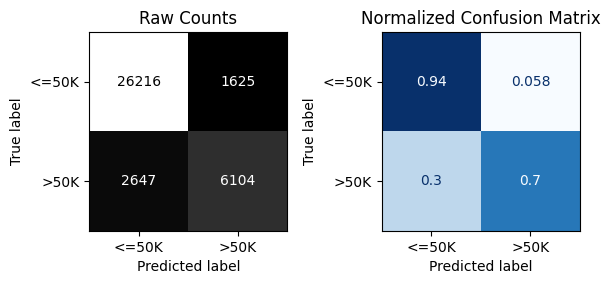


 Classification Metrics: Test Data
              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      9268
        >50K       0.67      0.59      0.63      2930

    accuracy                           0.83     12198
   macro avg       0.77      0.75      0.76     12198
weighted avg       0.83      0.83      0.83     12198



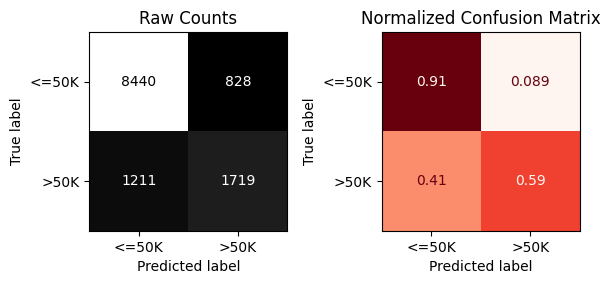

In [89]:
#Obtain evaluation metrics using custom function
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

In [90]:
#Git list of param for the KNN pipeline to choose a list of hyperparameters for tunning
knn_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
          'hours-per-week'],
         dtype='object')),
                                   ('categorical',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='MISSING',
                                                                   strategy='constant')),
                                                    ('onehotencoder',
                                                     OneHotEnco

In [92]:
#create param grid to use it with GridSearch CV
param_grid_knn = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 11, 15,17,19,21,23,25],
    "kneighborsclassifier__weights": ["uniform", "distance"],
    "kneighborsclassifier__p": [1, 2]
}

#Instantiate the GridSearchCV for hyperparameter tuning
grid_knn = GridSearchCV(
    knn_pipe,
    param_grid_knn,
    cv=3,
    scoring="recall_macro",
    n_jobs=-1,
    verbose=1
)

#Fitting the gridsearchcv on the training data
grid_knn.fit(X_train, y_train)

#Print out the Best Parameters after tuning
print("Best Parameters:", grid_knn.best_params_)

Fitting 3 folds for each of 44 candidates, totalling 132 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.73626571 0.74343083 0.74114359        nan 0.74337574
 0.75192182 0.74777996        nan 0.74650707 0.75614202 0.75126233
        nan 0.74777564 0.75842598 0.75371611        nan 0.75110932
 0.75728503 0.75436927        nan 0.7514833  0.75508128 0.75382413
        nan 0.75097241 0.75636935 0.75493102        nan 0.75289716
 0.758521   0.75553178        nan 0.75236169 0.75704205 0.75508612
        nan 0.75234056 0.75674335 0.75500127        nan 0.7516941
 0.75557122 0.75447402]
  warnings.warn(


Best Parameters: {'kneighborsclassifier__n_neighbors': 19, 'kneighborsclassifier__p': 2, 'kneighborsclassifier__weights': 'uniform'}


 Classification Metrics: Training Data
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91     27841
        >50K       0.73      0.63      0.68      8751

    accuracy                           0.86     36592
   macro avg       0.81      0.78      0.79     36592
weighted avg       0.85      0.86      0.85     36592



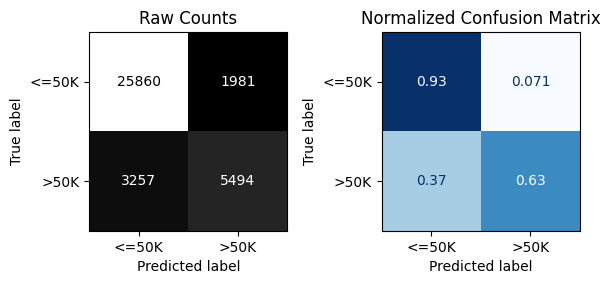


 Classification Metrics: Test Data
              precision    recall  f1-score   support

       <=50K       0.87      0.92      0.90      9268
        >50K       0.71      0.58      0.64      2930

    accuracy                           0.84     12198
   macro avg       0.79      0.75      0.77     12198
weighted avg       0.83      0.84      0.84     12198



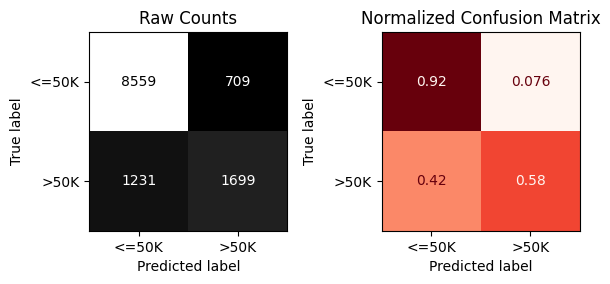

In [93]:
# Evaluate the optimized model
evaluate_classification(grid_knn.best_estimator_, X_train, y_train, X_test, y_test)